# Semi-Supervised Learning Pipeline with DBSCAN & SVM

This notebook implements a Semi-Supervised Learning (SSL) workflow. Unlike traditional supervised learning, this approach uses a small amount of labeled data to "teach" the model how to label a much larger set of unlabeled data, using density-based clustering as a structural guide.

1. Project Overview

The pipeline is divided into the following stages:

- Data Partitioning: We split the data into 50% labeled (for initial training) and 50% unlabeled (for structural discovery).

- Baseline SVM: Training a Support Vector Machine on only the labeled data to set a benchmark.

- DBSCAN Clustering: Grouping the unlabeled data based on density to identify natural patterns.

- Pseudo-Labeling: Predicting labels for the unlabeled clusters and keeping only the most "confident" predictions (Threshold >= 0.95).

- Model Enhancement: Retraining the SVM on the combined dataset to improve performance.

2. Environment & Imports

This section loads the essential data science stack.

- Key Tool: We use sklearn.cluster.DBSCAN for grouping and sklearn.svm.SVC for classification.

- Configuration: Includes a fixed seed for reproducibility so your experiments can be repeated with the same results.

In [37]:
# Imports and environment setup
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import DBSCAN
from sklearn.svm import SVC

# Settings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set(style='whitegrid', context='notebook')
print('Environment ready.')

Environment ready.


3. Configuration & Helpers 

This cell centralizes all "hyperparameters."

- DBSCAN Settings: DBSCAN_EPS (search radius) and DBSCAN_MIN_SAMPLES (minimum density) are defined here. These control how many clusters the algorithm finds.

- Threshold: PSEUDO_THRESHOLD = 0.95 ensures we only label unlabeled data if the model is extremely certain.

In [ ]:
# Configuration and utilities
DATASET_CANDIDATES = [
    '../../../dataset/cicids2017_sample_1M_natural_standardized.csv',
]
LABEL_CANDIDATES = ['label', 'Label', 'Attack', 'class', 'Class', 'category', 'target', 'y']

# Semi-supervised settings
TEST_SIZE = 0.2
RECORD_LIMITS = {
    'mode': 'custom',   # 'all' or 'custom'
    'train_n': 10000,
    'test_n': 1000,
}
LABELED_FRAC = 0.5  # 50% labeled, 50% unlabeled
PSEUDO_THRESHOLD = 0.95  # confidence threshold for pseudo-labeling
SAMPLE_FRAC = None
RANDOM_STATE = 42

#DBScan settings
DBSCAN_EPS = 6
DBSCAN_MIN_SAMPLES = 10

def pick_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

def load_any_dataset(candidates):
    path = pick_existing_path(candidates)
    if path is None:
        raise FileNotFoundError('No dataset found in candidates: ' + str(candidates))
    ext = os.path.splitext(path)[1].lower()
    if ext in ['.parquet']:
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path, low_memory=False)
    print(f'Loaded dataset: {path} | shape={df.shape}')
    return df

def find_label_col(df, candidates=LABEL_CANDIDATES):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError('Could not infer label column. Checked: ' + str(candidates))

def select_numeric_features(df):
    X_num = df.select_dtypes(include=[np.number])
    if X_num.shape[1] == 0:
        X_num = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
        X_num = X_num.select_dtypes(include=[np.number])
    return X_num

def stratified_labeled_unlabeled_split(X, y, labeled_frac=0.5, random_state=42):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=1 - labeled_frac, random_state=random_state)
    idx = np.arange(len(y))
    labeled_idx, unlabeled_idx = next(sss.split(idx, y))
    return labeled_idx, unlabeled_idx

def plot_conf_matrix(cm, classes, title='Confusion matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

print('Config ready.')


Config ready.


4. Data Preprocessing & Splitting

Handles the data "plumbing" to ensure a clean experiment:

- Binary Classification: Automatically detects the target column and maps labels like "Benign" or "Normal" to 0 and everything else to 1 (Abnormal).

- Leakage Prevention: This is critical. The StandardScaler is fitted only on labeled data. This ensures the model doesn't "cheat" by seeing the distribution of the test or unlabeled data ahead of time.

In [ ]:
# Load, preprocess, and split data
df = load_any_dataset(DATASET_CANDIDATES)
if SAMPLE_FRAC and 0 < SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

label_col = find_label_col(df)
df = df.dropna(how='any').reset_index(drop=True)

y_raw = df[label_col].astype(str)
X_num = select_numeric_features(df.drop(columns=[label_col]))

# Drop inf rows and extreme-value columns
inf_mask = np.isinf(X_num.values).any(axis=1)
if inf_mask.sum():
    X_num, y_raw = X_num[~inf_mask].reset_index(drop=True), y_raw[~inf_mask].reset_index(drop=True)
extreme_cols = (X_num.abs() > np.finfo(np.float64).max / 2).any()
if extreme_cols.any():
    X_num = X_num.loc[:, ~extreme_cols]

train_features = X_num.columns.tolist()

# Binary encode: Normal=0, Abnormal=1; stratify on original multi-class labels
le_full = LabelEncoder()
y_all = le_full.fit_transform(y_raw)
y_enc = np.where(y_raw.str.lower().isin(['benign', 'normal']), 0, 1).astype(int)
classes = ['Normal', 'Abnormal']
strat_y = y_all if np.bincount(y_all).min() >= 2 else y_enc

if RECORD_LIMITS.get('mode') == 'custom':
    train_n, test_n = RECORD_LIMITS.get('train_n'), RECORD_LIMITS.get('test_n')
    sss = StratifiedShuffleSplit(1, train_size=train_n, test_size=test_n, random_state=RANDOM_STATE)
    train_idx, test_idx = next(sss.split(np.arange(len(y_enc)), strat_y))
    X_train, X_test = X_num.values[train_idx], X_num.values[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_num.values, y_enc, test_size=TEST_SIZE, stratify=strat_y, random_state=RANDOM_STATE)

labeled_idx, unlabeled_idx = stratified_labeled_unlabeled_split(X_train, y_train, LABELED_FRAC, RANDOM_STATE)
X_labeled, y_labeled = X_train[labeled_idx], y_train[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

scaler = StandardScaler()
X_labeled_s   = scaler.fit_transform(X_labeled)
X_unlabeled_s = scaler.transform(X_unlabeled)
X_test_s      = scaler.transform(X_test)
print(f'Features={len(train_features)} | Train={X_train.shape[0]} (labeled={len(y_labeled)}, unlabeled={len(X_unlabeled)}) | Test={X_test.shape[0]}')


Loaded dataset: ../../../dataset/cicids2017_sample_1M_natural_standardized.csv | shape=(864031, 79)
Detected label column: Label
Dropping 275 rows containing inf/-inf values.
Using numeric features: 78
Binary classes: ['Normal', 'Abnormal']
Train: (100000, 78) Test: (10000, 78)
Labeled: (50000, 78) | Unlabeled: (50000, 78)
Scaling complete.


5. Baseline Supervised Model 

We train the initial Support Vector Classifier (SVC).

- Baseline: Since we only use 50% of the training data, this represents the model's performance without the benefit of SSL.

- Output: You will see a Confusion Matrix showing exactly where the model struggles (e.g., misclassifying Abnormal traffic as Normal).

Baseline supervised (labeled fraction=0.50) results:
              precision    recall  f1-score   support

      Normal     0.9734    0.9813    0.9773      7418
    Abnormal     0.9449    0.9229    0.9338      2582

    accuracy                         0.9662     10000
   macro avg     0.9591    0.9521    0.9555     10000
weighted avg     0.9660    0.9662    0.9661     10000



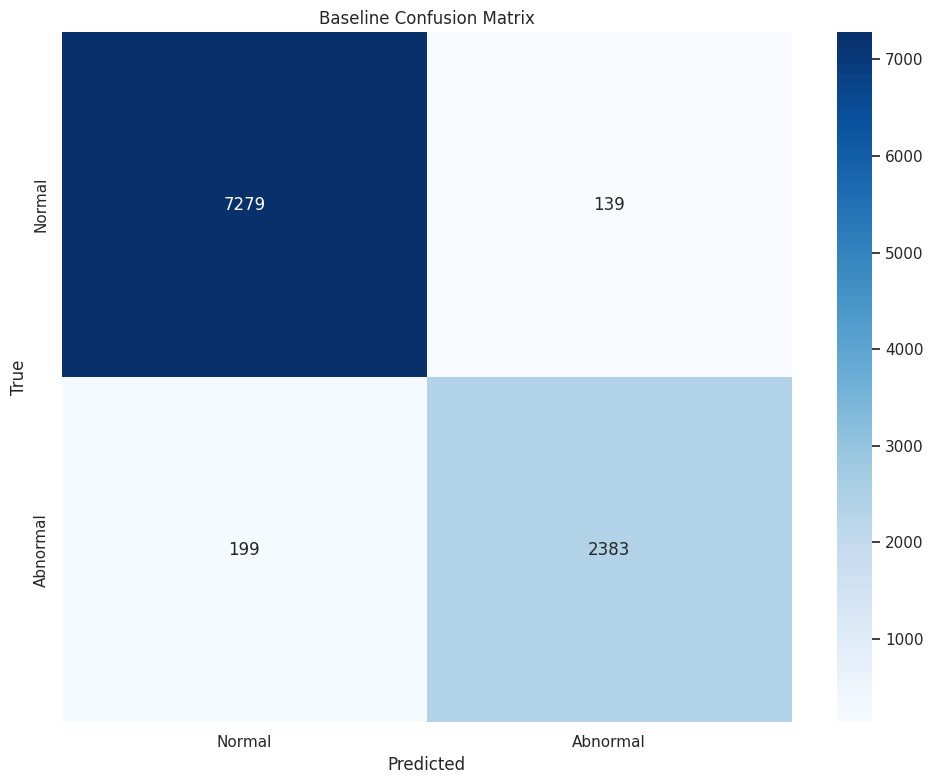

Baseline macro-F1: 0.9555433871288161


: 

In [ ]:
# Baseline (labeled data only)
baseline = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
baseline.fit(X_labeled_s, y_labeled)
y_pred_base = baseline.predict(X_test_s)
print(classification_report(y_test, y_pred_base, labels=[0,1], target_names=classes, digits=4, zero_division=0))
plot_conf_matrix(confusion_matrix(y_test, y_pred_base), classes, 'Baseline Confusion Matrix')
print('Baseline macro-F1:', round(f1_score(y_test, y_pred_base, average='macro'), 4))


6. DBSCAN & Pseudo-Labeling 

The core logic of the semi-supervised approach:

- DBSCAN: Clusters the unlabeled data. Points that are too isolated are marked as noise (-1) and discarded.

- Logic: We take a sample from an unlabeled cluster. If our baseline model is 95% sure of its label AND it belongs to a valid cluster, we treat that prediction as a "Pseudo-Label."

- Retraining: We train a final SVM using the original labeled data plus our new high-confidence pseudo-labels.

In [ ]:
# Semi-Supervised: DBSCAN + pseudo-labeling
clusterer = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
cluster_labels = clusterer.fit_predict(X_unlabeled_s)
n_clusters = len(set(cluster_labels) - {-1})
print(f'Clusters: {n_clusters} | Noise: {(cluster_labels == -1).sum()}')

proba = baseline.predict_proba(X_unlabeled_s)
max_proba, pseudo_preds = proba.max(axis=1), baseline.predict(X_unlabeled_s)
confident_mask = (max_proba >= PSEUDO_THRESHOLD) & (cluster_labels != -1)
X_pseudo, y_pseudo = X_unlabeled_s[confident_mask], pseudo_preds[confident_mask]
print(f'Pseudo-labeled: {confident_mask.sum()}/{len(X_unlabeled_s)} ({confident_mask.mean()*100:.1f}%)')

X_combined = np.vstack([X_labeled_s, X_pseudo])
y_combined = np.concatenate([y_labeled, y_pseudo])

ssl = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
ssl.fit(X_combined, y_combined)

y_pred_ssl = ssl.predict(X_test_s)
print(classification_report(y_test, y_pred_ssl, labels=[0,1], target_names=classes, digits=4, zero_division=0))
plot_conf_matrix(confusion_matrix(y_test, y_pred_ssl), classes, 'SSL (DBSCAN) Confusion Matrix')
f1_base = f1_score(y_test, y_pred_base, average='macro')
f1_ssl  = f1_score(y_test, y_pred_ssl,  average='macro')
print(f'Macro-F1 — Baseline: {f1_base:.4f}  SSL: {f1_ssl:.4f}  Δ: {f1_ssl - f1_base:+.4f}')


--- Step 1: DBSCAN clustering on unlabeled data ---


7. Saving Artifacts 

The final step saves everything needed for a production environment. It exports the trained ssl_svm.joblib along with the scaler and feature list, so you can make predictions on new, unseen data later.

In [ ]:
# Save trained models and preprocessing artifacts (DBSCAN + SVM version)
import joblib
import os

ART_DIR = 'artifacts'
os.makedirs(ART_DIR, exist_ok=True)
saved = []

# Save Baseline SVM (nếu có)
if 'baseline' in globals():
    joblib.dump({
        'model': baseline,
        'scaler': scaler,
        'features': train_features,
        'classes': classes,
        'label_encoding': {'normal': 0, 'abnormal': 1}
    }, os.path.join(ART_DIR, 'baseline_svm.joblib'))
    saved.append('baseline_svm.joblib')

# Save SSL (DBSCAN + SVM)
if 'ssl' in globals():
    joblib.dump({
        'model': ssl,           
        'scaler': scaler,           
        'features': train_features,
        'classes': classes,
        'label_encoding': {'normal': 0, 'abnormal': 1},
        'dbscan_params': {
            'eps': DBSCAN_EPS,       
            'min_samples': DBSCAN_MIN_SAMPLES,
        },
    }, os.path.join(ART_DIR, 'ssl_svm.joblib'))
    saved.append('ssl_svm.joblib')

print('---')
print('Artifacts directory:', ART_DIR)
print('Saved files:', saved if saved else 'Nothing saved (Check variable names: baseline_svm or ssl_svm).')

---
Artifacts directory: artifacts
Saved files: ['baseline_svm.joblib', 'ssl_svm.joblib']
